In [1]:
import warnings
warnings.filterwarnings('ignore')
 
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import random
from tqdm import tqdm
 
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
 
import tensorflow as tf
from tensorflow.keras.utils import to_categorical, Sequence
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Dense, Conv2D, Dropout, BatchNormalization,
    Activation, Add, GlobalAveragePooling2D, Input
)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import LearningRateScheduler, ModelCheckpoint

2026-04-09 17:05:19.845528: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775754320.035328      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775754320.090561      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775754320.554886      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775754320.554925      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775754320.554928      24 computation_placer.cc:177] computation placer alr

In [2]:
# ==========================
# PATHS
# ==========================
BASE_PATH      = "/kaggle/input/competitions/shift-guard-10-robust-image-classification-challenge"
TRAIN_IMG_PATH = os.path.join(BASE_PATH, "train_images")
TEST_IMG_PATH  = os.path.join(BASE_PATH, "test_images")
LABEL_PATH     = os.path.join(BASE_PATH, "train_labels.csv")
CLASS_PATH     = os.path.join(BASE_PATH, "classes.txt")
 
IMG_SIZE   = 32
N_TTA      = 15
EPOCHS     = 200
BATCH_SIZE = 128
INIT_LR    = 0.1
WARMUP_EP  = 5
 

In [3]:
# ==========================
# LOAD CLASS NAMES & LABELS
# ==========================
with open(CLASS_PATH) as f:
    class_names = [line.strip() for line in f.readlines()]
num_classes = len(class_names)
print(f"Classes ({num_classes}):", class_names)
 
labels_df = pd.read_csv(LABEL_PATH)
 
# ==========================
# LOAD TRAIN IMAGES
# ==========================
images, labels = [], []
for _, row in tqdm(labels_df.iterrows(), total=len(labels_df)):
    image_name = f"{row['id']:06d}.png"
    img = cv2.imread(os.path.join(TRAIN_IMG_PATH, image_name))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    images.append(img)
    labels.append(class_names.index(row['label']))
 
X = np.array(images, dtype='float32')
y = np.array(labels)
print("Dataset shape:", X.shape, y.shape)
 
# ==========================
# TRAIN / VALID SPLIT
# (done once; both models see same val set)
# ==========================
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y
)
 

Classes (10): ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


100%|██████████| 29400/29400 [02:18<00:00, 212.41it/s]


Dataset shape: (29400, 32, 32, 3) (29400,)


In [4]:
# ==========================
# PER-CHANNEL NORMALIZATION
# ==========================
mean = X_train.mean(axis=(0, 1, 2), keepdims=True)
std  = X_train.std(axis=(0, 1, 2), keepdims=True)
 
X_train_n = (X_train - mean) / (std + 1e-7)
X_valid_n = (X_valid - mean) / (std + 1e-7)
 
# ==========================
# LOAD & NORMALIZE TEST IMAGES
# ==========================
test_images, test_ids = [], []
for file in sorted(os.listdir(TEST_IMG_PATH)):
    img = cv2.imread(os.path.join(TEST_IMG_PATH, file))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    test_images.append(img)
    stem = os.path.splitext(file)[0]
    test_ids.append(f"{int(stem):06d}")
 
X_test = (np.array(test_images, dtype='float32') - mean) / (std + 1e-7)
print("Test shape:", X_test.shape)
 
y_train_oh = to_categorical(y_train, num_classes)
y_valid_oh = to_categorical(y_valid, num_classes)
 

Test shape: (7600, 32, 32, 3)


In [5]:
# ==========================
# RANDAUGMENT
# ==========================
 
def rand_augment(img, n_ops=2, magnitude=9):
    img_u = np.clip(img * std[0,0,0] + mean[0,0,0], 0, 255).astype(np.uint8)
    ops = [
        _ra_identity, _ra_auto_contrast, _ra_equalize, _ra_rotate,
        _ra_solarize, _ra_color, _ra_contrast, _ra_brightness,
        _ra_sharpness, _ra_shear_x, _ra_shear_y,
        _ra_translate_x, _ra_translate_y,
    ]
    chosen = random.sample(ops, k=min(n_ops, len(ops)))
    m = magnitude / 30.0
    for op in chosen:
        img_u = op(img_u, m)
    img_f = img_u.astype('float32')
    return (img_f - mean[0,0,0]) / (std[0,0,0] + 1e-7)
 
 
def _clamp(img):
    return np.clip(img, 0, 255).astype(np.uint8)
 
def _ra_identity(img, m):       return img
def _ra_auto_contrast(img, m):
    for c in range(3):
        lo, hi = img[:,:,c].min(), img[:,:,c].max()
        if hi > lo:
            img[:,:,c] = ((img[:,:,c].astype(float)-lo)/(hi-lo)*255).astype(np.uint8)
    return img
def _ra_equalize(img, m):
    out = img.copy()
    for c in range(3):
        out[:,:,c] = cv2.equalizeHist(img[:,:,c])
    return out
def _ra_rotate(img, m):
    angle = m * 30 * random.choice([-1, 1])
    h, w  = img.shape[:2]
    M     = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)
    return cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REFLECT)
def _ra_solarize(img, m):
    threshold = int((1 - m) * 256)
    lut = np.array([i if i < threshold else 255-i for i in range(256)], dtype=np.uint8)
    return lut[img]
def _ra_color(img, m):
    factor = 1.0 + m * random.choice([-1, 1])
    gray   = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    gray3  = np.stack([gray]*3, axis=-1)
    return _clamp(gray3 + factor * (img.astype(float) - gray3))
def _ra_contrast(img, m):
    factor = 1.0 + m * random.choice([-1, 1])
    mean_c = img.mean()
    return _clamp(mean_c + factor * (img.astype(float) - mean_c))
def _ra_brightness(img, m):
    delta = int(m * 63 * random.choice([-1, 1]))
    return _clamp(img.astype(int) + delta)
def _ra_sharpness(img, m):
    kernel = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]], dtype=np.float32)
    sharp  = cv2.filter2D(img, -1, kernel)
    return _clamp((1 - m) * img.astype(float) + m * sharp.astype(float))
def _ra_shear_x(img, m):
    shear = m * 0.3 * random.choice([-1, 1])
    h, w  = img.shape[:2]
    M = np.float32([[1, shear, 0],[0, 1, 0]])
    return cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REFLECT)
def _ra_shear_y(img, m):
    shear = m * 0.3 * random.choice([-1, 1])
    h, w  = img.shape[:2]
    M = np.float32([[1, 0, 0],[shear, 1, 0]])
    return cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REFLECT)
def _ra_translate_x(img, m):
    tx = int(m * img.shape[1] * 0.33 * random.choice([-1, 1]))
    M  = np.float32([[1, 0, tx],[0, 1, 0]])
    return cv2.warpAffine(img, M, (img.shape[1], img.shape[0]),
                          borderMode=cv2.BORDER_REFLECT)
def _ra_translate_y(img, m):
    ty = int(m * img.shape[0] * 0.33 * random.choice([-1, 1]))
    M  = np.float32([[1, 0, 0],[0, 1, ty]])
    return cv2.warpAffine(img, M, (img.shape[1], img.shape[0]),
                          borderMode=cv2.BORDER_REFLECT)
 
 

In [6]:
# ==========================
# DATA GENERATOR
# ==========================
 
class RobustAugGenerator(Sequence):
 
    def __init__(self, X, y, batch_size=128, augment=True,
                 mixup_alpha=0.2, cutmix_alpha=1.0,
                 cutout_n_holes=2, cutout_length=8,
                 randaug_n=2, randaug_m=9):
        self.X              = X
        self.y              = y
        self.batch_size     = batch_size
        self.augment        = augment
        self.mixup_alpha    = mixup_alpha
        self.cutmix_alpha   = cutmix_alpha
        self.cutout_n_holes = cutout_n_holes
        self.cutout_length  = cutout_length
        self.randaug_n      = randaug_n
        self.randaug_m      = randaug_m
        self.indices        = np.arange(len(X))
 
    def __len__(self):
        return len(self.X) // self.batch_size
 
    def on_epoch_end(self):
        np.random.shuffle(self.indices)
 
    def _rand_augment_batch(self, batch_x):
        out = batch_x.copy()
        for i in range(len(out)):
            out[i] = rand_augment(out[i], n_ops=self.randaug_n,
                                  magnitude=self.randaug_m)
        return out
 
    def _spatial_aug(self, batch_x):
        h, w, pad = batch_x.shape[1], batch_x.shape[2], 4
        flip = np.random.rand(len(batch_x)) > 0.5
        batch_x[flip] = batch_x[flip, :, ::-1, :]
        padded = np.pad(batch_x, ((0,0),(pad,pad),(pad,pad),(0,0)), mode='reflect')
        out = np.empty_like(batch_x)
        for i in range(len(batch_x)):
            top  = np.random.randint(0, pad * 2)
            left = np.random.randint(0, pad * 2)
            out[i] = padded[i, top:top+h, left:left+w, :]
        return out
 
    def _cutout(self, batch_x):
        h, w = batch_x.shape[1], batch_x.shape[2]
        out  = batch_x.copy()
        for img in out:
            for _ in range(self.cutout_n_holes):
                cy, cx = np.random.randint(h), np.random.randint(w)
                l = self.cutout_length
                y1, y2 = max(0, cy - l//2), min(h, cy + l//2)
                x1, x2 = max(0, cx - l//2), min(w, cx + l//2)
                img[y1:y2, x1:x2] = 0.0
        return out
 
    def _mixup(self, bx, by):
        lam  = np.random.beta(self.mixup_alpha, self.mixup_alpha)
        perm = np.random.permutation(len(bx))
        return lam * bx + (1-lam) * bx[perm], \
               lam * by + (1-lam) * by[perm]
 
    def _cutmix(self, bx, by):
        h, w = bx.shape[1], bx.shape[2]
        lam  = np.random.beta(self.cutmix_alpha, self.cutmix_alpha)
        perm = np.random.permutation(len(bx))
        cut_ratio = np.sqrt(1.0 - lam)
        ch, cw = int(h * cut_ratio), int(w * cut_ratio)
        cy, cx = np.random.randint(h), np.random.randint(w)
        y1, y2 = max(0, cy - ch//2), min(h, cy + ch//2)
        x1, x2 = max(0, cx - cw//2), min(w, cx + cw//2)
        mixed_x = bx.copy()
        mixed_x[:, y1:y2, x1:x2, :] = bx[perm, y1:y2, x1:x2, :]
        lam_adj = 1.0 - (y2-y1)*(x2-x1) / (h*w)
        return mixed_x, lam_adj * by + (1-lam_adj) * by[perm]
 
    def __getitem__(self, idx):
        batch_idx = self.indices[idx*self.batch_size : (idx+1)*self.batch_size]
        bx = self.X[batch_idx].copy()
        by = self.y[batch_idx].copy()
        if self.augment:
            bx = self._rand_augment_batch(bx)
            bx = self._spatial_aug(bx)
            bx = self._cutout(bx)
            if np.random.rand() < 0.5:
                bx, by = self._mixup(bx, by)
            else:
                bx, by = self._cutmix(bx, by)
        return bx, by
 

In [7]:
# ==========================
# WIDERESNET BUILDER
# ==========================
 
def wide_residual_block(x, out_filters, stride=1,
                        dropout_rate=0.3, wd=5e-4):
    in_filters = x.shape[-1]
    shortcut   = x
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    if stride != 1 or in_filters != out_filters:
        shortcut = Conv2D(out_filters, 1, strides=stride, padding='same',
                         use_bias=False, kernel_regularizer=l2(wd))(x)
    x = Conv2D(out_filters, 3, strides=stride, padding='same',
               use_bias=False, kernel_regularizer=l2(wd))(x)
    if dropout_rate > 0:
        x = Dropout(dropout_rate)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Conv2D(out_filters, 3, padding='same',
               use_bias=False, kernel_regularizer=l2(wd))(x)
    return Add()([x, shortcut])
 
 
def build_wideresnet(input_shape, num_classes,
                     depth=28, widen_factor=6,
                     dropout_rate=0.3, wd=5e-4):
    assert (depth - 4) % 6 == 0
    n  = (depth - 4) // 6
    k  = widen_factor
    nf = [16, 16*k, 32*k, 64*k]
 
    inputs = Input(shape=input_shape)
    x = Conv2D(nf[0], 3, padding='same', use_bias=False,
               kernel_regularizer=l2(wd))(inputs)
 
    for filters, stride in zip(nf[1:], [1, 2, 2]):
        x = wide_residual_block(x, filters, stride=stride,
                                dropout_rate=dropout_rate, wd=wd)
        for _ in range(n - 1):
            x = wide_residual_block(x, filters, stride=1,
                                    dropout_rate=dropout_rate, wd=wd)
 
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = GlobalAveragePooling2D()(x)
    outputs = Dense(num_classes, activation='softmax',
                    kernel_regularizer=l2(wd))(x)
    return Model(inputs, outputs)
 

In [8]:
# ==========================
# LR SCHEDULE
# ==========================
 
def warmup_cosine_lr(epoch):
    if epoch < WARMUP_EP:
        return INIT_LR * (epoch + 1) / WARMUP_EP
    progress = (epoch - WARMUP_EP) / (EPOCHS - WARMUP_EP)
    return INIT_LR * 0.5 * (1.0 + np.cos(np.pi * progress))
 
 
# ==========================
# TTA PREDICT
# ==========================
 
def _tta_jitter(X):
    aug  = X.copy()
    aug += np.random.uniform(-0.1, 0.1)
    mu   = aug.mean(axis=(1,2), keepdims=True)
    aug  = mu + np.random.uniform(0.9, 1.1) * (aug - mu)
    return aug
 
def tta_predict(model, X, n_tta=N_TTA):
    h, w = X.shape[1], X.shape[2]
    pad  = 4
    preds = model.predict(X, verbose=0)
    for _ in range(n_tta - 1):
        aug  = X.copy()
        flip = np.random.rand(len(aug)) > 0.5
        aug[flip] = aug[flip, :, ::-1, :]
        padded  = np.pad(aug, ((0,0),(pad,pad),(pad,pad),(0,0)), mode='reflect')
        cropped = np.empty_like(aug)
        for i in range(len(aug)):
            top  = np.random.randint(0, pad*2)
            left = np.random.randint(0, pad*2)
            cropped[i] = padded[i, top:top+h, left:left+w, :]
        cropped = _tta_jitter(cropped)
        preds  += model.predict(cropped, verbose=0)
    return preds / n_tta
 
 

In [9]:
# ============================================================
# TRAIN TWO MODELS WITH DIFFERENT SEEDS & SLIGHT DIVERSITY
# Model 1 : seed=42,  dropout=0.30
# Model 2 : seed=123, dropout=0.25  (slightly less dropout
#            → different regularisation regime)
# ============================================================
 
MODEL_CONFIGS = [
    {"seed": 42,  "dropout": 0.30, "ckpt": "best_model_1.keras", "label": "Model-1"},
    {"seed": 123, "dropout": 0.25, "ckpt": "best_model_2.keras", "label": "Model-2"},
]
 
all_histories = {}
 
for cfg in MODEL_CONFIGS:
    print(f"\n{'='*60}")
    print(f"  Training {cfg['label']}  (seed={cfg['seed']}, dropout={cfg['dropout']})")
    print(f"{'='*60}")
 
    # --- reproducibility for this model ---
    random.seed(cfg["seed"])
    np.random.seed(cfg["seed"])
    tf.random.set_seed(cfg["seed"])
 
    # --- fresh generator (shuffle order differs per seed) ---
    train_gen = RobustAugGenerator(
        X_train_n, y_train_oh,
        batch_size=BATCH_SIZE,
        augment=True,
        mixup_alpha=0.2,
        cutmix_alpha=1.0,
        cutout_n_holes=2,
        cutout_length=8,
        randaug_n=2,
        randaug_m=9,
    )
 
    # --- fresh model ---
    model = build_wideresnet(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        num_classes=num_classes,
        depth=28,
        widen_factor=6,
        dropout_rate=cfg["dropout"],
        wd=5e-4,
    )
 
    optimizer = SGD(learning_rate=INIT_LR, momentum=0.9, nesterov=True)
    loss_fn   = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05)
    model.compile(optimizer=optimizer, loss=loss_fn, metrics=['accuracy'])
 
    lr_scheduler = LearningRateScheduler(warmup_cosine_lr, verbose=0)
    checkpoint   = ModelCheckpoint(
        cfg["ckpt"], monitor='val_accuracy',
        save_best_only=True, verbose=1,
    )
 
    history = model.fit(
        train_gen,
        epochs=EPOCHS,
        validation_data=(X_valid_n, y_valid_oh),
        callbacks=[lr_scheduler, checkpoint],
        verbose=2,
    )
    all_histories[cfg["label"]] = history
 


  Training Model-1  (seed=42, dropout=0.3)


I0000 00:00:1775754535.135415      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775754535.141579      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/200


I0000 00:00:1775754545.133866      73 service.cc:152] XLA service 0x7cb5440024e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775754545.133921      73 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1775754545.133927      73 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1775754546.631809      73 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1775754566.942455      73 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.



Epoch 1: val_accuracy improved from -inf to 0.40136, saving model to best_model_1.keras
206/206 - 97s - 471ms/step - accuracy: 0.3594 - loss: 4.4821 - val_accuracy: 0.4014 - val_loss: 4.3108 - learning_rate: 0.0200
Epoch 2/200

Epoch 2: val_accuracy improved from 0.40136 to 0.51259, saving model to best_model_1.keras
206/206 - 71s - 345ms/step - accuracy: 0.4362 - loss: 4.0762 - val_accuracy: 0.5126 - val_loss: 3.6831 - learning_rate: 0.0400
Epoch 3/200

Epoch 3: val_accuracy improved from 0.51259 to 0.52823, saving model to best_model_1.keras
206/206 - 71s - 343ms/step - accuracy: 0.4612 - loss: 3.6147 - val_accuracy: 0.5282 - val_loss: 3.1762 - learning_rate: 0.0600
Epoch 4/200

Epoch 4: val_accuracy did not improve from 0.52823
206/206 - 70s - 341ms/step - accuracy: 0.4814 - loss: 3.1252 - val_accuracy: 0.4888 - val_loss: 2.8810 - learning_rate: 0.0800
Epoch 5/200

Epoch 5: val_accuracy improved from 0.52823 to 0.54898, saving model to best_model_1.keras
206/206 - 71s - 343ms/step 

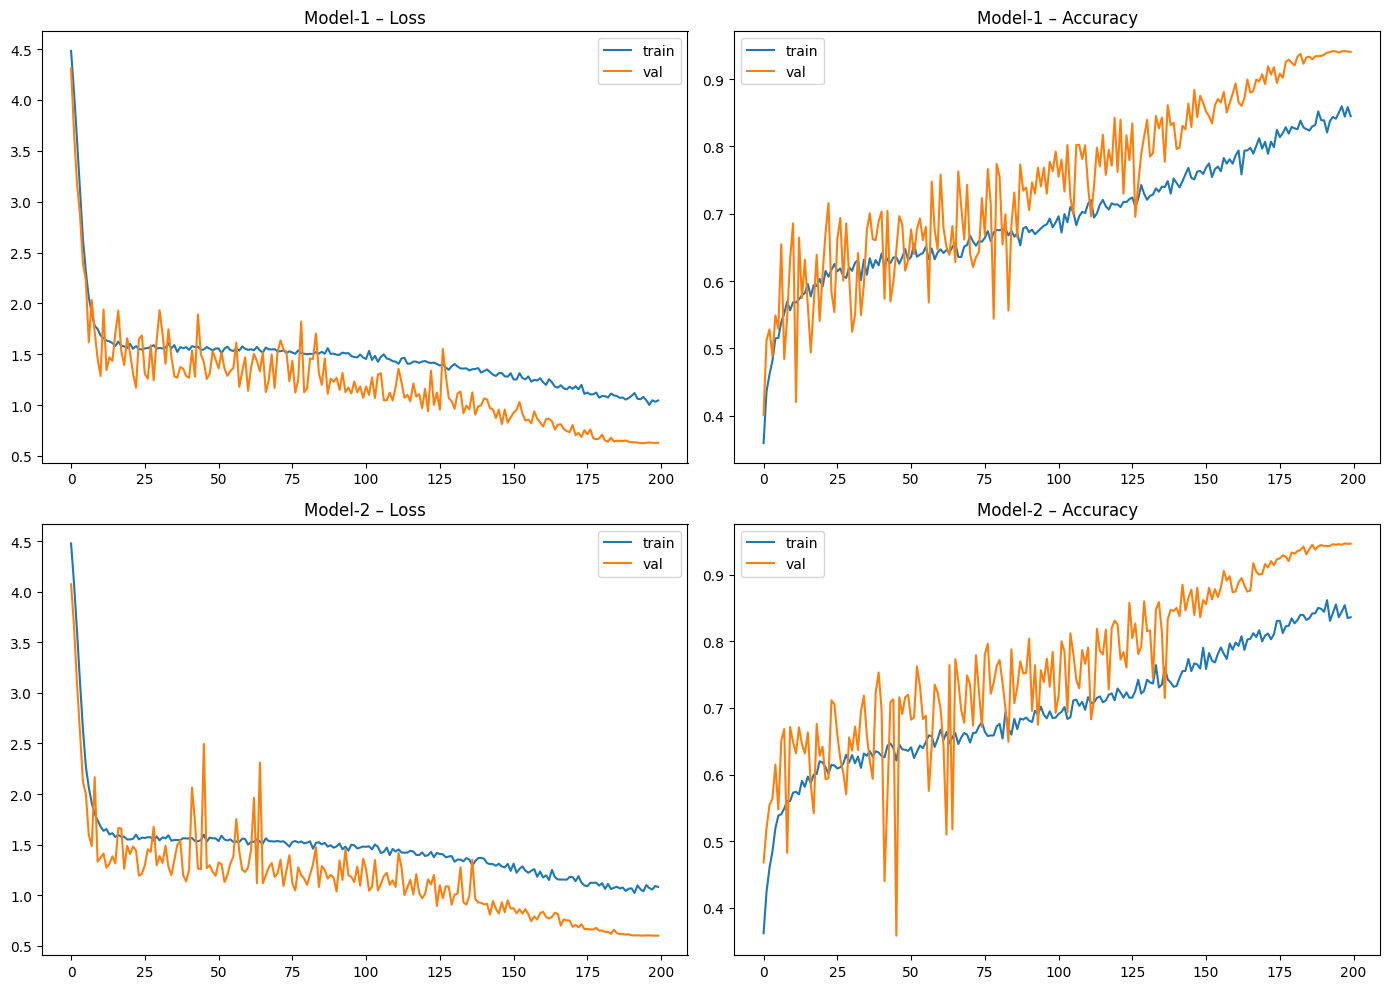

In [10]:
# ==========================
# TRAINING CURVES (both models)
# ==========================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for i, (lbl, history) in enumerate(all_histories.items()):
    axes[i][0].plot(history.history['loss'],     label='train')
    axes[i][0].plot(history.history['val_loss'], label='val')
    axes[i][0].set_title(f'{lbl} – Loss'); axes[i][0].legend()
    axes[i][1].plot(history.history['accuracy'],     label='train')
    axes[i][1].plot(history.history['val_accuracy'], label='val')
    axes[i][1].set_title(f'{lbl} – Accuracy'); axes[i][1].legend()
plt.tight_layout()
plt.savefig("training_curves_ensemble.png", dpi=120)
plt.show()


In [11]:
# ==========================
# ENSEMBLE INFERENCE
# Load both best checkpoints, run TTA on each,
# then average probabilities before argmax.
# ==========================
print("\nRunning ensemble TTA inference …")
 
ensemble_test_probs  = None
ensemble_valid_probs = None
 
for cfg in MODEL_CONFIGS:
    print(f"  Loading {cfg['ckpt']} …")
    model = build_wideresnet(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        num_classes=num_classes,
        depth=28,
        widen_factor=6,
        dropout_rate=cfg["dropout"],
        wd=5e-4,
    )
    model.load_weights(cfg["ckpt"])
 
    # reset seed so TTA augmentations differ between models
    random.seed(cfg["seed"] + 999)
    np.random.seed(cfg["seed"] + 999)
 
    print(f"    TTA on test  ({N_TTA} passes) …")
    t_probs = tta_predict(model, X_test,  n_tta=N_TTA)
    print(f"    TTA on valid ({N_TTA} passes) …")
    v_probs = tta_predict(model, X_valid_n, n_tta=N_TTA)
 
    ensemble_test_probs  = t_probs if ensemble_test_probs  is None else ensemble_test_probs  + t_probs
    ensemble_valid_probs = v_probs if ensemble_valid_probs is None else ensemble_valid_probs + v_probs
 
# Average over models
n_models = len(MODEL_CONFIGS)
ensemble_test_probs  /= n_models
ensemble_valid_probs /= n_models
 


Running ensemble TTA inference …
  Loading best_model_1.keras …
    TTA on test  (15 passes) …
    TTA on valid (15 passes) …
  Loading best_model_2.keras …
    TTA on test  (15 passes) …
    TTA on valid (15 passes) …


In [12]:
# ==========================
# VALIDATION F1
# ==========================
val_preds    = np.argmax(ensemble_valid_probs, axis=1)
val_true     = np.argmax(y_valid_oh, axis=1)
val_f1_macro = f1_score(val_true, val_preds, average='macro')
print(f"\nEnsemble Validation Macro F1 (with TTA): {val_f1_macro:.4f}")
 
# Individual model F1s for reference
for cfg in MODEL_CONFIGS:
    model = build_wideresnet(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        num_classes=num_classes, depth=28,
        widen_factor=6, dropout_rate=cfg["dropout"], wd=5e-4,
    )
    model.load_weights(cfg["ckpt"])
    v = tta_predict(model, X_valid_n, n_tta=N_TTA)
    f1 = f1_score(np.argmax(y_valid_oh, axis=1), np.argmax(v, axis=1), average='macro')
    print(f"  {cfg['label']} individual Macro F1: {f1:.4f}")
 


Ensemble Validation Macro F1 (with TTA): 0.9090
  Model-1 individual Macro F1: 0.8987
  Model-2 individual Macro F1: 0.9248


In [13]:
# ==========================
# SUBMISSION
# ==========================
pred_classes = np.argmax(ensemble_test_probs, axis=1)
pred_labels  = [class_names[i] for i in pred_classes]
 
submission = pd.DataFrame({"id": test_ids, "label": pred_labels})
submission["id"] = submission["id"].apply(lambda x: f"{int(x):06d}")
submission = submission.sort_values("id").reset_index(drop=True)
submission.to_csv("submission.csv", index=False)
 
print("\nsubmission.csv saved!")
print(submission.head(10))
print("\nClass distribution:\n", submission['label'].value_counts())


submission.csv saved!
       id       label
0  000001  automobile
1  000002  automobile
2  000003         dog
3  000004        frog
4  000005         dog
5  000006        bird
6  000007        frog
7  000008        bird
8  000009         dog
9  000010        bird

Class distribution:
 label
ship          906
frog          905
dog           855
deer          851
horse         833
automobile    722
truck         698
airplane      636
bird          599
cat           595
Name: count, dtype: int64
